# **Bitcoin Cycle Risk Model (0-100)**

A single composite score that answers one question: **where are we in the cycle?** 0 = cycle lows (historically the best place to buy), 100 = cycle highs (historically the best place to sell).

## How it is built

Three indicators, each ranked against its own trailing **4-year** distribution (one halving cycle), then blended with backtest-selected weights:

| Component | Weight | What it measures |
|---|---|---|
| `pl_resid` | 0.60 | Deviation of price from its own expanding power-law trend (refit on every bar, no lookahead) |
| `mvrv` | 0.20 | MVRV ratio - on-chain valuation vs. aggregate cost basis |
| `mult_730` | 0.20 | Price / 730-day MA (the 2-Year MA Multiplier) |

Weights were chosen by backtest, not by taste: the power-law residual carries nearly all of the predictive power, while MVRV and the 2-year multiple keep the score from resting on a single indicator. Weights are renormalised over whatever components are available on a given day, so the score survives CoinMetrics' on-chain feed running months behind.

Two variants are produced: `risk` (all three components) and `risk_price` (price-only, always live, and the one the projection extends).

## Validation

`validate_risk_model` checks the only thing that matters: does a high reading today actually mean poor forward returns? It reports median forward return and win rate per risk bucket at 90/180/365 days, plus the Spearman rank correlation.

**Honest reading of the results:** the edge is real but concentrated at the extremes and grows with the horizon. The 80-100 bucket has historically produced *negative* median returns at every horizon, and the bottom buckets strongly positive ones - but the middle of the range carries little information, and at 90 days the correlation is weak (statistically significant, but small). This is a cycle-position tool, not a short-term timing signal.

## Projection: historical analogs

`project_risk` does **not** simulate random price paths. A block-bootstrap Monte Carlo was tried first and discarded: resampling returns ignores the mean reversion and cycle structure the score itself demonstrates, so it degenerates into a widening cone centred on today's value - technically correct, practically useless.

Instead the projection is conditional and empirical. It finds every past episode that started at **today's risk level and today's 30-day direction of travel**, then shows what the score actually did over the following 6 months in each of those episodes, together with the BTC price return that came with it.

**Caveat, and it matters:** this rests on a handful of overlapping episodes drawn from only three completed cycles. Read the spread as "here is what happened the last few times", not as a calibrated probability.

*Not financial advice. Past relationships can and do break down.*


In [1]:
import sys
import sys, os
_base = os.getcwd()
while _base and not os.path.isdir(os.path.join(_base, 'functions')):
    _parent = os.path.dirname(_base)
    if _parent == _base: break
    _base = _parent
if os.path.abspath(_base) not in sys.path:
    sys.path.insert(0, os.path.abspath(_base))
from functions.functions_RiskModel import (
    load_dataframe,
    plot_risk_model,
    validate_risk_model,
    project_risk,
)
import warnings
warnings.filterwarnings("ignore")

df = load_dataframe()

✅ BTC data fetched from CoinMetrics: 6351 rows (last: 2026-05-24)


🔄 BTC PriceUSD topped up with Yahoo Finance through 2026-09-22 (122 extra day(s)); other on-chain fields carried forward from 2026-05-23


## The risk score through history

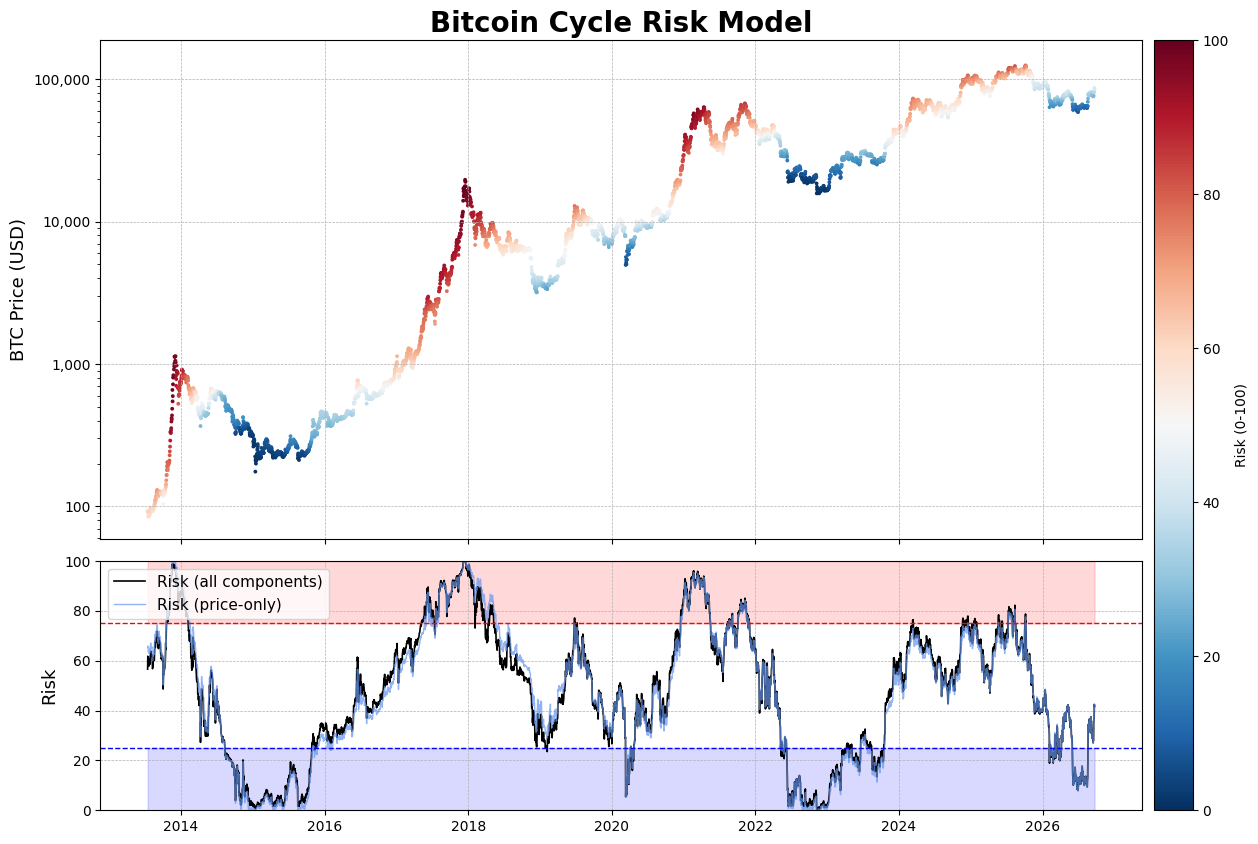

Latest reading (2026-09-22): risk = 41.7 / 100 (price-only: 41.7)


In [2]:
plot_risk_model(df)

## Validation: do high readings actually precede poor returns?

Forward returns by risk bucket

        90d median %  90d win rate %  180d median %  180d win rate %  365d median %  365d win rate %  n days
0-20             4.1            52.0           32.6             63.0           87.9             81.0     846
20-40           11.8            62.0           42.5             69.0          131.8             69.0    1014
40-60           16.5            61.0           32.2             61.0           82.0             71.0    1241
60-80            3.6            55.0            5.2             52.0           -2.8             48.0    1193
80-100         -14.5            44.0          -11.2             42.0          -29.1             34.0     524

Spearman rank correlation (risk vs forward return):
    90d: rho = -0.034   p = 1.79e-02   n = 4728
   180d: rho = -0.156   p = 1.67e-26   n = 4638
   365d: rho = -0.377   p = 1.08e-150   n = 4453


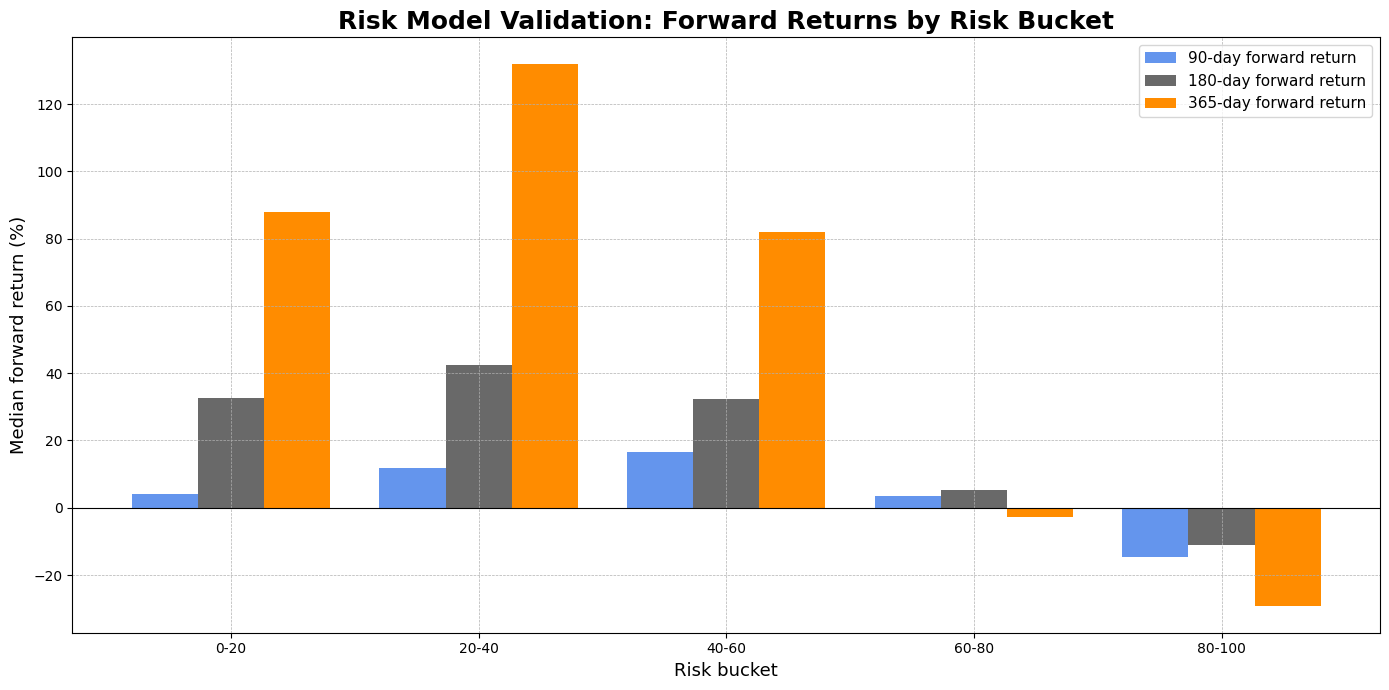

In [3]:
validation = validate_risk_model(df)

## Projection: what followed the closest historical analogs?

Risk today: 41.7  (30-day change: +8.2)

17 historical analogs - past episodes at a similar level and heading the same way
(tolerance +/-7 on level, +/-15 on 30-day change):
  2014-04, 2014-07, 2015-12, 2016-04, 2016-07, 2016-10, 2018-11, 2019-02, 2019-10, 2020-01, 2020-04, 2020-08, 2022-02, 2023-10, 2024-08, 2025-04, 2025-12

What happened over the following 180 days:
  Risk ended at:  median 55.5   quartiles 23.5 - 67.1   full range 1 - 96
  Touched the sell zone (>= 75): 29% of episodes
  Touched the buy zone  (<= 25): 41% of episodes
  BTC price return:  median +44.3%   range -67% to +406%   positive in 71% of episodes


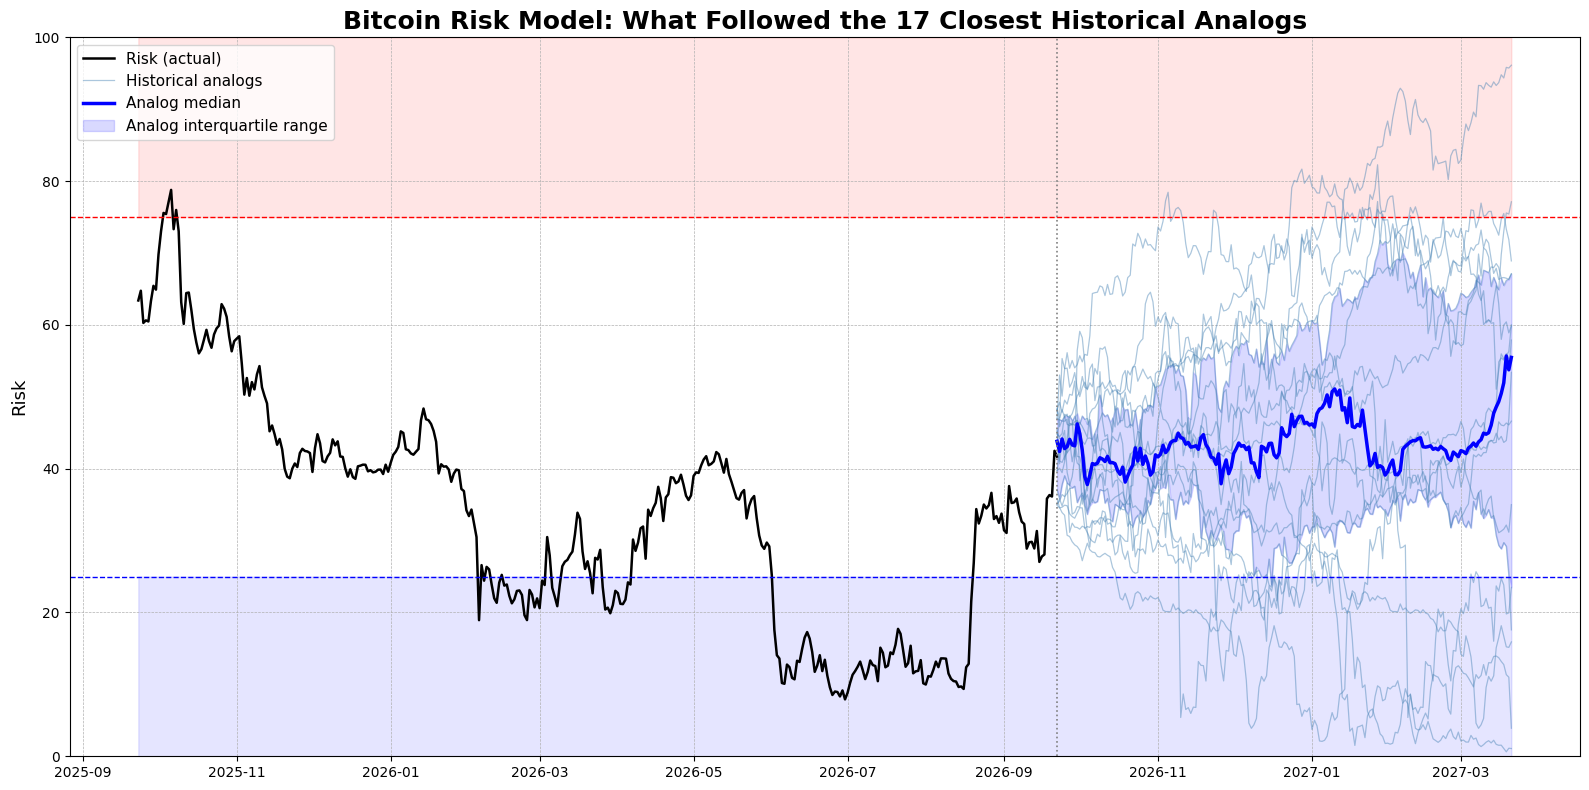

In [4]:
projection = project_risk(df, horizon_days=180)